# ___`corHMM` practice___
----------------------------

In [3]:
library("ape")
library("corHMM")

In [4]:
packageVersion("corHMM")

[1] '2.8'

In [25]:
# use the primates dataset for practice as demonstrated in the package vignette
data(primates)
tree <- ape::multi2di(primates[[1]])
data <- primates[[2]]

In [26]:
tree # 60 species


Phylogenetic tree with 60 tips and 59 internal nodes.

Tip labels:
  Homo_sapiens, Pan_paniscus, Pan_troglodytes, Gorilla_gorilla, Pongo_pygmaeus, Pongo_pygmaeus_abelii, ...

Rooted; includes branch length(s).

In [27]:
head(data) # two categorical traits?

,Genus_sp,T1,T2
,<fct>,<int>,<int>
1,Cercocebus_torquatus,1,1
2,Cercopithecus_aethiops,0,1
3,Cercopithecus_mona,0,0
4,Cercopithecus_nictitans,0,0
5,Colobus_angolensis,0,1
6,Colobus_guereza,0,0


In [28]:
length(tree$tip.label) == dim(data)[1] # good :)

[1] TRUE

In [29]:
# sort the dataset to match the species order in the phylogeny
data <- data[match(x = tree$tip.label, data$Genus_sp), ]
stopifnot(all.equal(data$Genus_sp, as.factor(tree$tip.label)))

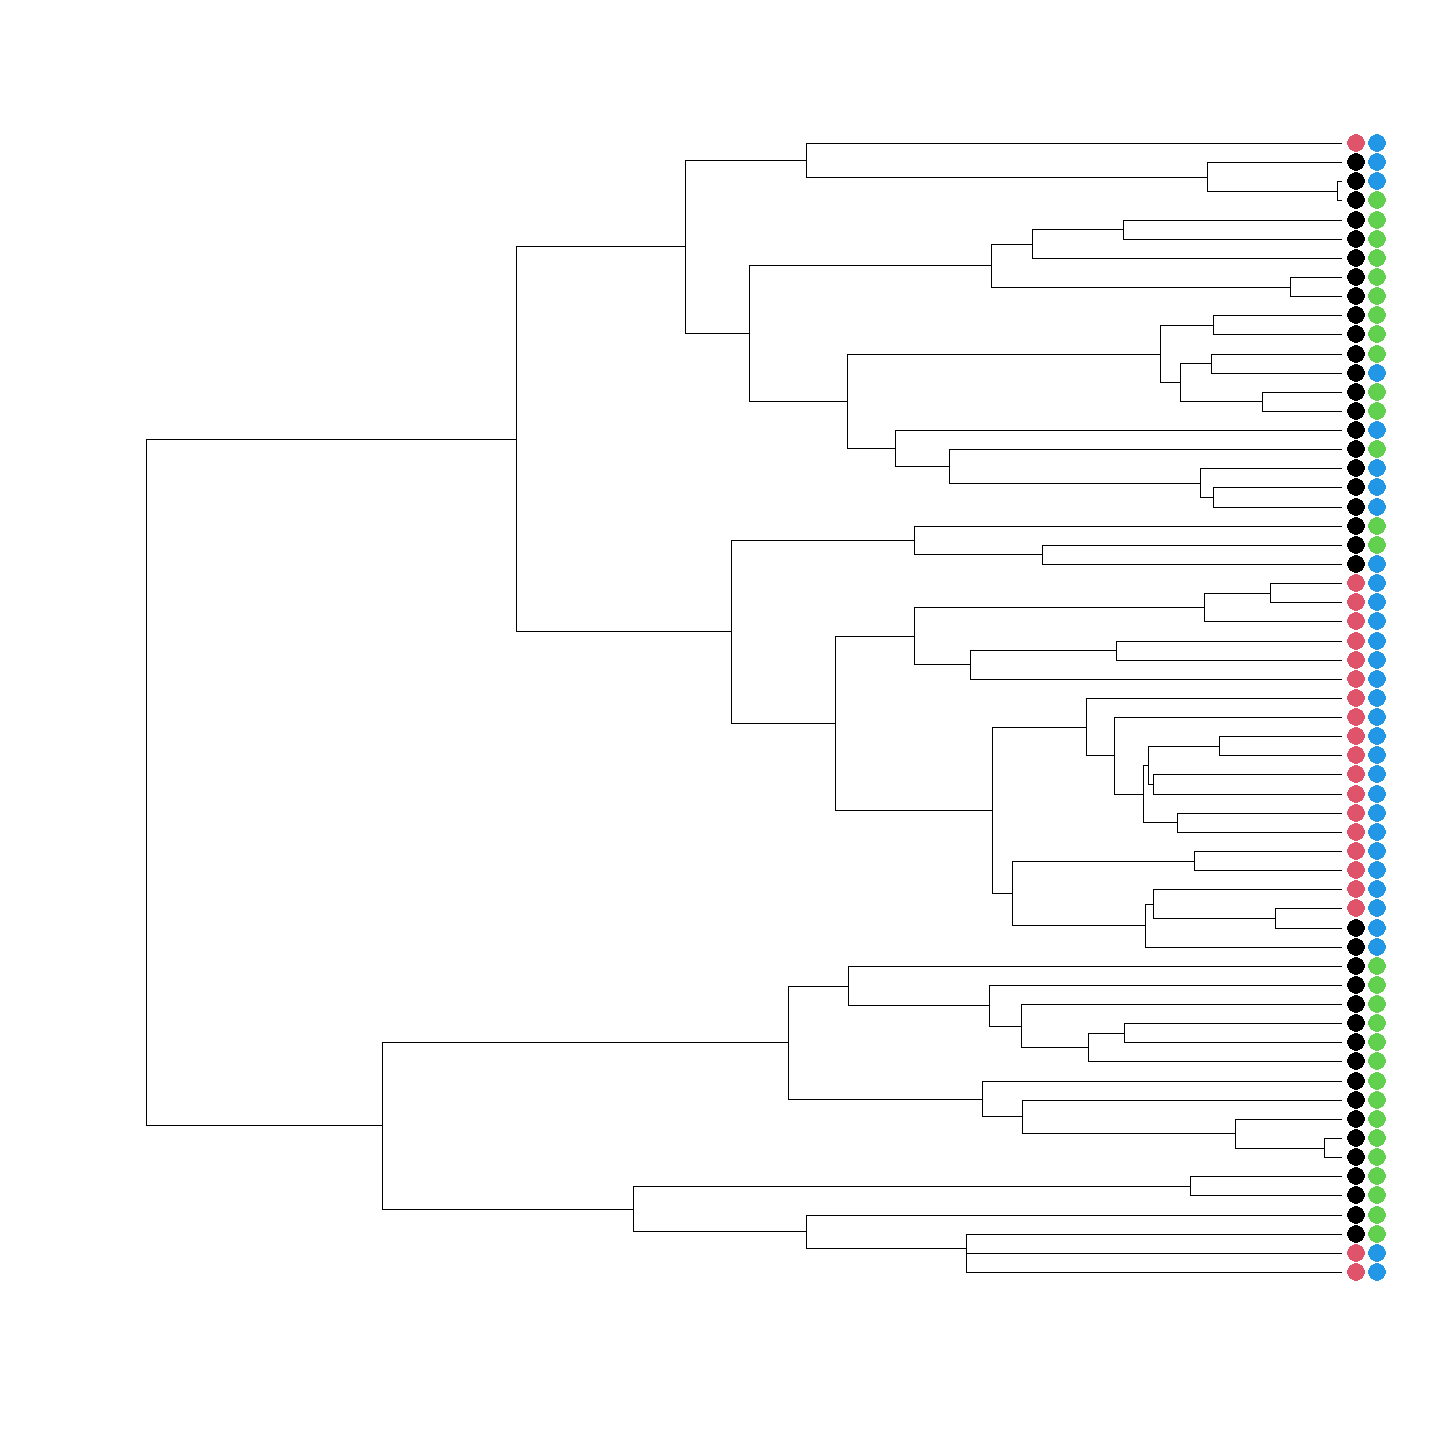

In [51]:
options(repr.plot.width = 12, repr.plot.height = 12)
plot(tree, show.tip.label = FALSE)
tiplabels(pch = 16, col = data$T1 + 1, cex = 2, offset = 0.6) # first column of circles - T1
tiplabels(pch = 16, col = data$T2 + 3, cex = 2, offset = 1.5) # second column of circles - T2

In [52]:
baseMM <- corHMM::corHMM(phy = tree, data = data, rate.cat = 1) # no hidden states

Warning message in corHMM::corHMM(phy = tree, data = data, rate.cat = 1):
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	
Counts:	29	10	21	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 


In [54]:
baseMM # these are the corHMM outputs


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -41.90867 91.81734 92.54461        1   60

Legend
    1     2     3 
"0_0" "0_1" "1_1" 

Rates
           (1,R1)     (2,R1)     (3,R1)
(1,R1)         NA 0.01900076         NA
(2,R1) 0.05664411         NA 0.02627018
(3,R1)         NA 0.01610503         NA

Arrived at a reliable solution 

In [65]:
# even though we had two categorical traits with two states in each, we only see three transitions in the legend
# why is that??
print(unique(paste0(as.character(data$T1), '_', as.character(data$T2))))

[1] "0_0" "1_1" "0_1"


In [61]:
# it seems that not all the 4 possible combinations exist in our dataset, as simpla as that

In [67]:
# we can also create and use the rate matrix manually, using our data
print(corHMM::getStateMat4Dat(data))

$legend
    1     2     3 
"0_0" "0_1" "1_1" 

$rate.mat
    (1) (2) (3)
(1)   0   2   0
(2)   1   0   4
(3)   0   3   0

